In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
fake = pd.read_csv(r"C:\Users\my\Desktop\Fake.csv")
true = pd.read_csv(r"C:\Users\my\Desktop\True.csv")

C:\Users\my\AppData\Local\Temp\ipykernel_14240\1023099911.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171) have mixed types. Specify dtype option on import or set low_memory=False.
  fake = pd.read_csv(r"C:\Users\my\Desktop\Fake.csv")


In [5]:
fake.head()

,title,text,subject,date,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 162,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,31-Dec-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,31-Dec-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,30-Dec-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,29-Dec-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,25-Dec-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,31-Dec-17
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,29-Dec-17
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,31-Dec-17
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,30-Dec-17
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,29-Dec-17


In [7]:
fake.shape

(23502, 172)

In [8]:
true.shape

(21417, 4)

In [9]:
fake.columns

Index(['title', 'text', 'subject', 'date', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 162', 'Unnamed: 163', 'Unnamed: 164', 'Unnamed: 165',
       'Unnamed: 166', 'Unnamed: 167', 'Unnamed: 168', 'Unnamed: 169',
       'Unnamed: 170', 'Unnamed: 171'],
      dtype='object', length=172)

In [10]:
fake["label"] = 0
true["label"] = 1

In [11]:
data = pd.concat([fake, true], axis=0)

In [12]:
data = data.sample(frac=1)

In [13]:
data = data[['text','label']]

In [14]:
data.head()

,text,label
8739,NaN,0
10964,NaN,0
6417,NaN,1
13307,NaN,0
14488,NaN,1


In [25]:
import re

def clean_text(text):
    
    text = str(text)   # convert to string
    
    text = text.lower()
    
    text = re.sub(r'\W', ' ', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text

In [26]:
data['text'] = data['text'].apply(clean_text)

In [27]:
X = data['text']
y = data['label']

In [28]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [29]:
vectorizer = TfidfVectorizer()

In [30]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [31]:
model = LogisticRegression()

In [32]:
model.fit(X_train_vec,y_train)

LogisticRegression()

In [33]:
y_pred = model.predict(X_test_vec)

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.53      1.00      0.69      4712
           1       0.97      0.02      0.03      4272

    accuracy                           0.53      8984
   macro avg       0.75      0.51      0.36      8984
weighted avg       0.74      0.53      0.38      8984



In [35]:
news = ["India launches new satellite for communication"]

vec = vectorizer.transform(news)

model.predict(vec)

array([1])

In [53]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [54]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\my\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [55]:
stop_words = set(stopwords.words('english'))

ps = PorterStemmer()

def clean_text(text):
    
    text = str(text)
    
    text = text.lower()
    
    text = re.sub(r'\W',' ',text)
    
    words = text.split()
    
    words = [ps.stem(word) for word in words if word not in stop_words]
    
    return " ".join(words)

In [56]:
data['text'] = data['text'].apply(clean_text)

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [58]:
vectorizer = TfidfVectorizer(max_features=5000)

In [59]:
X = vectorizer.fit_transform(data['text'])
y = data['label']

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [62]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [63]:
y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.5327248441674087

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

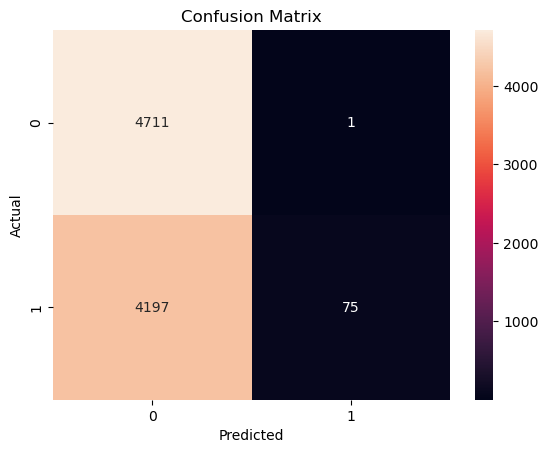

In [66]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

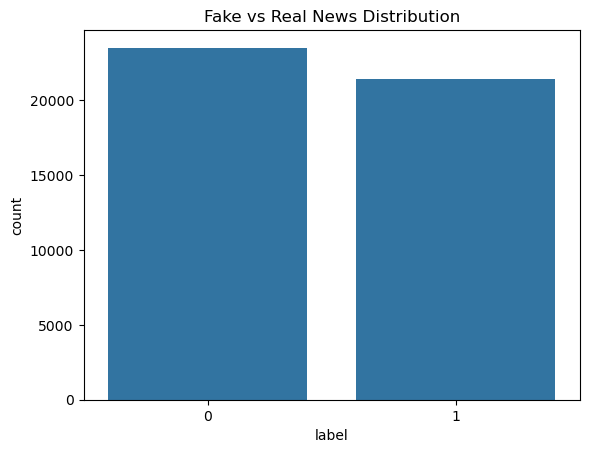

In [67]:
sns.countplot(x=data['label'])

plt.title("Fake vs Real News Distribution")

plt.show()


In [68]:
news = ["NASA announces new mission to Mars"]

vec = vectorizer.transform(news)

prediction = model.predict(vec)

if prediction[0] == 1:
    
    print("Real News")
    
else:
    
    print("Fake News")

Fake News
